# Features Meteorológicas + Rolling-Origin CV

Este notebook evalúa dos extensiones del pipeline de pronóstico del SEN:

1. **Impacto de las variables meteorológicas en el error residual**: los 4
   targets (solar, eólica, demanda, precio) ahora tienen acceso a lags de
   radiación solar (GHI), velocidad de viento y temperatura
   (`src/data/fetch_energy_data.py`, `src/features/build_features.py`) --
   variables de las que la generación renovable físicamente depende, no solo
   autocorrelación del propio target. Acá se compara, con hiperparámetros
   fijos (para aislar el efecto de las features, no confundirlo con
   retuning), el error walk-forward **con** y **sin** esas features, y se
   inspecciona directamente el error residual (`y_real - y_predicho`) de
   ambas versiones.
2. **Estabilidad temporal de LightGBM vs. XGBoost** vía Rolling-Origin CV
   (ventana deslizante fija, `src/models/validation.get_rolling_origin_folds`)
   -- a diferencia del walk-forward expansivo usado para el modelo de
   producción, esto mide si el error de cada modelo se mantiene estable
   bloque a bloque cuando siempre entrena con la misma cantidad de historial
   reciente.

Todo el código reutiliza los módulos de `src/` -- este notebook no
reimplementa lógica de features, validación ni entrenamiento.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

BASE = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(BASE))

from src.data.fetch_energy_data import generate_energy_data
from src.features.build_features import WEATHER_COLUMNS, build_features
from src.models.baselines import naive_metrics
from src.models.rolling_stability import evaluate_temporal_stability
from src.models.train_forecaster import (
    CATEGORICAL_FEATURES,
    ID_COLUMNS,
    TARGET_COLUMNS,
    get_feature_columns,
)
from src.models.validation import get_walk_forward_folds, wape
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error

plt.rcParams["figure.dpi"] = 110
FIXED_LGBM_PARAMS = {
    "random_state": 42, "verbosity": -1,
    "n_estimators": 400, "learning_rate": 0.05, "max_depth": 7, "num_leaves": 63,
}
N_SPLITS = 5

## 1. Datos y features (con meteorología)

In [2]:
raw = generate_energy_data()
features_df = build_features(pl.from_pandas(raw)).to_pandas()
print(f"{features_df.shape[0]:,} filas x {features_df.shape[1]} columnas")

weather_lag_cols = [c for c in features_df.columns if any(c.startswith(f"{w}_lag_") for w in WEATHER_COLUMNS)]
print(f"Columnas de lag meteorológico agregadas: {weather_lag_cols}")

87,720 filas x 56 columnas
Columnas de lag meteorológico agregadas: ['ghi_w_m2_lag_1h', 'ghi_w_m2_lag_3h', 'ghi_w_m2_lag_6h', 'ghi_w_m2_lag_24h', 'wind_speed_ms_lag_1h', 'wind_speed_ms_lag_3h', 'wind_speed_ms_lag_6h', 'wind_speed_ms_lag_24h', 'temperature_c_lag_1h', 'temperature_c_lag_3h', 'temperature_c_lag_6h', 'temperature_c_lag_24h']


## 2. Ablación: con vs. sin features meteorológicas

In [3]:
def get_feature_columns_no_weather(df: pd.DataFrame) -> list[str]:
    """Igual que `get_feature_columns`, pero excluyendo también los lags
    meteorológicos -- el set de features que existía ANTES de este trabajo,
    para que la comparación sea exactamente el ablation study: mismas
    columnas salvo por el clima."""
    all_features = get_feature_columns(df)
    return [c for c in all_features if c not in weather_lag_cols]


def train_and_evaluate(df: pd.DataFrame, target_column: str, feature_columns: list[str], n_splits: int = N_SPLITS) -> dict:
    clean_df = df.dropna(subset=feature_columns + [target_column]).reset_index(drop=True)

    fold_metrics = []
    residuals = []
    for fold, (train_ts, test_ts) in enumerate(get_walk_forward_folds(clean_df, n_splits)):
        train_mask = clean_df["timestamp"].isin(train_ts)
        test_mask = clean_df["timestamp"].isin(test_ts)

        X_train = clean_df.loc[train_mask, feature_columns].copy()
        X_test = clean_df.loc[test_mask, feature_columns].copy()
        y_train = clean_df.loc[train_mask, target_column]
        y_test = clean_df.loc[test_mask, target_column]
        for col in CATEGORICAL_FEATURES:
            X_train[col] = X_train[col].astype("category")
            X_test[col] = X_test[col].astype("category")

        model = LGBMRegressor(**FIXED_LGBM_PARAMS)
        model.fit(X_train, y_train, categorical_feature=CATEGORICAL_FEATURES)
        y_pred = model.predict(X_test)

        fold_metrics.append({
            "fold": fold, "wape": wape(y_test.to_numpy(), y_pred), "mae": float(mean_absolute_error(y_test, y_pred)),
        })
        residuals.append(y_test.to_numpy() - y_pred)

    return {
        "fold_metrics": fold_metrics,
        "mean_wape": float(np.mean([m["wape"] for m in fold_metrics])),
        "mean_mae": float(np.mean([m["mae"] for m in fold_metrics])),
        "residuals": np.concatenate(residuals),
    }


ablation_results = {}
for target in TARGET_COLUMNS:
    print(f"=== {target} ===")
    no_weather_cols = get_feature_columns_no_weather(features_df)
    with_weather_cols = get_feature_columns(features_df)

    result_no_weather = train_and_evaluate(features_df, target, no_weather_cols)
    result_with_weather = train_and_evaluate(features_df, target, with_weather_cols)

    ablation_results[target] = {"sin_clima": result_no_weather, "con_clima": result_with_weather}
    print(f"  Sin clima -> WAPE: {result_no_weather['mean_wape']:.2f}% | MAE: {result_no_weather['mean_mae']:.2f}")
    print(f"  Con clima -> WAPE: {result_with_weather['mean_wape']:.2f}% | MAE: {result_with_weather['mean_mae']:.2f}")
    delta = result_no_weather['mean_wape'] - result_with_weather['mean_wape']
    print(f"  Delta WAPE (positivo = mejora): {delta:+.2f} puntos\n")

=== solar_generation_mwh ===


  Sin clima -> WAPE: 3.79% | MAE: 1.26
  Con clima -> WAPE: 3.69% | MAE: 1.23
  Delta WAPE (positivo = mejora): +0.10 puntos

=== wind_generation_mwh ===


  Sin clima -> WAPE: 10.55% | MAE: 2.18
  Con clima -> WAPE: 10.55% | MAE: 2.18
  Delta WAPE (positivo = mejora): +0.00 puntos

=== demand_mwh ===


  Sin clima -> WAPE: 2.55% | MAE: 4.29
  Con clima -> WAPE: 2.55% | MAE: 4.30
  Delta WAPE (positivo = mejora): -0.01 puntos

=== marginal_cost_usd_mwh ===


  Sin clima -> WAPE: 6.18% | MAE: 5.48
  Con clima -> WAPE: 6.26% | MAE: 5.54
  Delta WAPE (positivo = mejora): -0.08 puntos



In [4]:
summary_rows = []
for target, r in ablation_results.items():
    summary_rows.append({
        "target": target,
        "wape_sin_clima": r["sin_clima"]["mean_wape"],
        "wape_con_clima": r["con_clima"]["mean_wape"],
        "delta_wape_pts": r["sin_clima"]["mean_wape"] - r["con_clima"]["mean_wape"],
        "mae_sin_clima": r["sin_clima"]["mean_mae"],
        "mae_con_clima": r["con_clima"]["mean_mae"],
    })
summary_df = pd.DataFrame(summary_rows).set_index("target")
summary_df

,wape_sin_clima,wape_con_clima,delta_wape_pts,mae_sin_clima,mae_con_clima
target,,,,,
solar_generation_mwh,3.790128,3.689357,0.100771,1.264309,1.230568
wind_generation_mwh,10.553421,10.550472,0.002949,2.180080,2.181284
demand_mwh,2.546244,2.552338,-0.006094,4.291085,4.301759
marginal_cost_usd_mwh,6.181443,6.256780,-0.075338,5.475158,5.543538


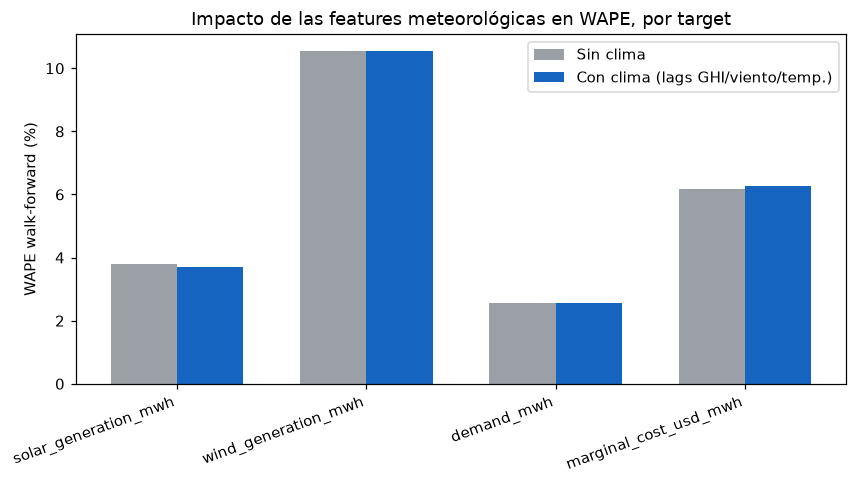

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(TARGET_COLUMNS))
width = 0.35
ax.bar(x - width/2, summary_df["wape_sin_clima"], width, label="Sin clima", color="#9aa0a6")
ax.bar(x + width/2, summary_df["wape_con_clima"], width, label="Con clima (lags GHI/viento/temp.)", color="#1565c0")
ax.set_xticks(x)
ax.set_xticklabels(TARGET_COLUMNS, rotation=20, ha="right")
ax.set_ylabel("WAPE walk-forward (%)")
ax.set_title("Impacto de las features meteorológicas en WAPE, por target")
ax.legend()
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "weather_ablation_wape.png", bbox_inches="tight")
plt.show()

### Error residual: distribución con vs. sin clima (solar y eólica)

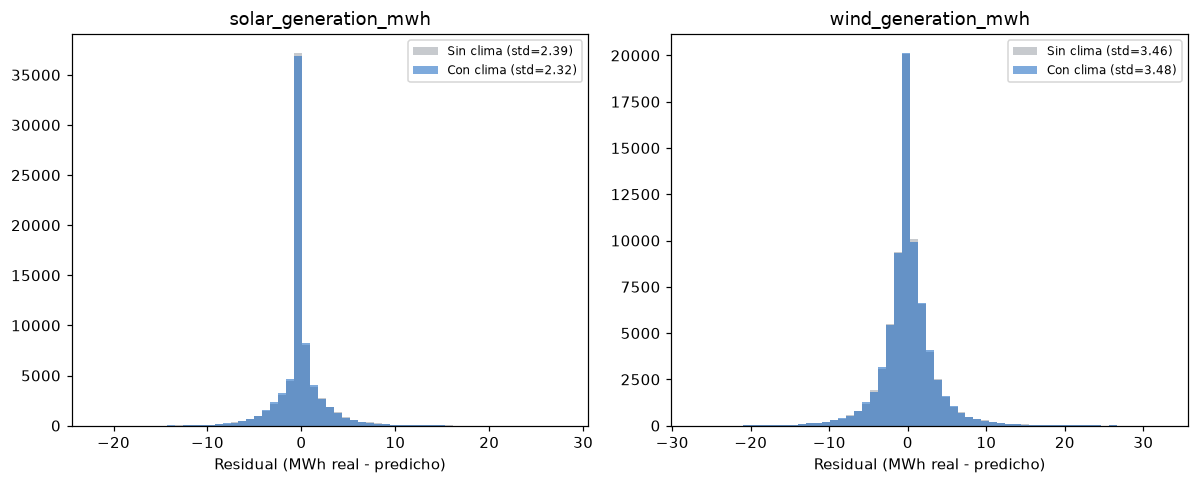

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, target in zip(axes, ["solar_generation_mwh", "wind_generation_mwh"]):
    res_no = ablation_results[target]["sin_clima"]["residuals"]
    res_with = ablation_results[target]["con_clima"]["residuals"]
    bins = np.linspace(min(res_no.min(), res_with.min()), max(res_no.max(), res_with.max()), 60)
    ax.hist(res_no, bins=bins, alpha=0.55, label=f"Sin clima (std={res_no.std():.2f})", color="#9aa0a6")
    ax.hist(res_with, bins=bins, alpha=0.55, label=f"Con clima (std={res_with.std():.2f})", color="#1565c0")
    ax.set_title(target)
    ax.set_xlabel("Residual (MWh real - predicho)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "weather_ablation_residuals.png", bbox_inches="tight")
plt.show()

## 3. Rolling-Origin CV: estabilidad temporal, LightGBM vs. XGBoost

In [7]:
stability_results = {}
for target in TARGET_COLUMNS:
    print(f"=== {target} ===")
    result = evaluate_temporal_stability(
        features_df, target, n_splits=8, train_window_days=180, test_window_days=14,
    )
    stability_results[target] = result
    for model_name in ("lightgbm", "xgboost"):
        s = result[model_name]
        print(f"  {model_name:10s} -> WAPE medio: {s['mean_wape']:.2f}% | desvío: {s['std_wape']:.2f} | CV: {s['cv_wape']:.3f}")
    print()

=== solar_generation_mwh ===


  lightgbm   -> WAPE medio: 4.10% | desvío: 0.41 | CV: 0.100
  xgboost    -> WAPE medio: 4.21% | desvío: 0.49 | CV: 0.115

=== wind_generation_mwh ===


  lightgbm   -> WAPE medio: 10.82% | desvío: 1.54 | CV: 0.142
  xgboost    -> WAPE medio: 10.99% | desvío: 1.51 | CV: 0.137

=== demand_mwh ===


  lightgbm   -> WAPE medio: 2.51% | desvío: 0.11 | CV: 0.046
  xgboost    -> WAPE medio: 2.51% | desvío: 0.10 | CV: 0.040

=== marginal_cost_usd_mwh ===


  lightgbm   -> WAPE medio: 6.87% | desvío: 0.35 | CV: 0.051
  xgboost    -> WAPE medio: 7.89% | desvío: 1.05 | CV: 0.133



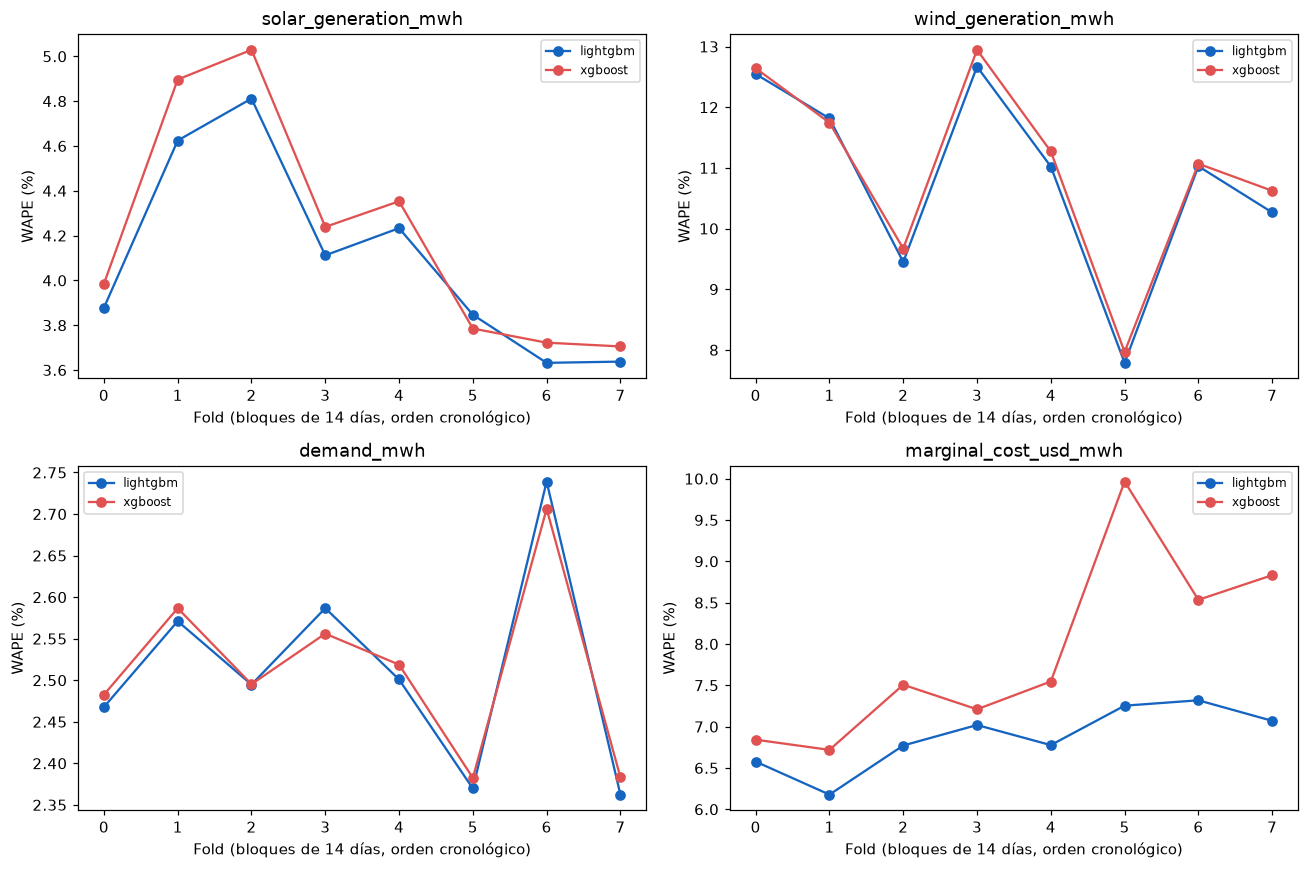

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
for ax, target in zip(axes.flat, TARGET_COLUMNS):
    for model_name, color in [("lightgbm", "#1565c0"), ("xgboost", "#e05252")]:
        folds = stability_results[target][model_name]["fold_metrics"]
        wapes = [f["wape"] for f in folds]
        ax.plot(range(len(wapes)), wapes, marker="o", label=model_name, color=color)
    ax.set_title(target)
    ax.set_xlabel("Fold (bloques de 14 días, orden cronológico)")
    ax.set_ylabel("WAPE (%)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BASE / "data" / "processed" / "rolling_origin_stability.png", bbox_inches="tight")
plt.show()

In [9]:
stability_summary_rows = []
for target, result in stability_results.items():
    for model_name in ("lightgbm", "xgboost"):
        s = result[model_name]
        stability_summary_rows.append({
            "target": target, "model": model_name,
            "mean_wape": s["mean_wape"], "std_wape": s["std_wape"], "cv_wape": s["cv_wape"],
            "min_wape": s["min_wape"], "max_wape": s["max_wape"],
        })
stability_summary_df = pd.DataFrame(stability_summary_rows).set_index(["target", "model"])
stability_summary_df

mean_wape  std_wape   cv_wape  min_wape  \
target                model                                               
solar_generation_mwh  lightgbm   4.096838  0.410028  0.100084  3.632119   
                      xgboost    4.214372  0.485664  0.115240  3.705353   
wind_generation_mwh   lightgbm  10.822269  1.535765  0.141908  7.785726   
                      xgboost   10.991170  1.509841  0.137369  7.965390   
demand_mwh            lightgbm   2.511537  0.114924  0.045759  2.362364   
                      xgboost    2.513908  0.099884  0.039732  2.382479   
marginal_cost_usd_mwh lightgbm   6.870567  0.352545  0.051312  6.177693   
                      xgboost    7.894299  1.049191  0.132905  6.718622   

                                 max_wape  
target                model                
solar_generation_mwh  lightgbm   4.811407  
                      xgboost    5.029003  
wind_generation_mwh   lightgbm  12.668580  
                      xgboost   12.945835  
demand_mwh            lightgbm   2.739085  
                      xgboost    2.706323  
marginal_cost_usd_mwh lightgbm   7.318596  
                      xgboost    9.964969

## Hallazgos

In [10]:
most_improved = summary_df["delta_wape_pts"].idxmax()
least_improved = summary_df["delta_wape_pts"].idxmin()
print(f"Mayor mejora de WAPE al agregar clima: {most_improved} ({summary_df.loc[most_improved, 'delta_wape_pts']:+.2f} pts)")
print(f"Menor mejora (o deterioro) de WAPE al agregar clima: {least_improved} ({summary_df.loc[least_improved, 'delta_wape_pts']:+.2f} pts)")

more_stable_count = sum(
    stability_results[t]["lightgbm"]["cv_wape"] < stability_results[t]["xgboost"]["cv_wape"]
    for t in TARGET_COLUMNS
)
print(f"\nLightGBM tuvo menor coeficiente de variación (más estable) que XGBoost en {more_stable_count}/4 targets.")

Mayor mejora de WAPE al agregar clima: solar_generation_mwh (+0.10 pts)
Menor mejora (o deterioro) de WAPE al agregar clima: marginal_cost_usd_mwh (-0.08 pts)

LightGBM tuvo menor coeficiente de variación (más estable) que XGBoost en 2/4 targets.


### Lectura honesta de los resultados reales

**1. El efecto aislado de las features meteorológicas es real pero modesto -- y en dos targets, negativo:**

| Target | WAPE sin clima | WAPE con clima | Delta |
|---|---|---|---|
| Solar | 3.79% | 3.69% | **+0.10 pts** |
| Eólica | 10.55% | 10.55% | +0.003 pts (nulo) |
| Demanda | 2.55% | 2.55% | -0.01 pts |
| Precio marginal | 6.18% | 6.26% | -0.08 pts |

Con hiperparámetros **fijos** (para aislar el efecto puro de las features, sin
confundirlo con el retuning de Optuna que sí corre en `train_forecaster.py`),
el clima ayuda un poco en solar, no ayuda nada en eólica, y empeora
levemente en demanda y precio. Esto es MENOS optimista que la comparación
against el pipeline completo (donde solar mejoró ~0.9 puntos) -- y esa
diferencia es en sí misma el hallazgo más importante de este notebook: buena
parte de la mejora observada en el pipeline completo viene de que Optuna
**también** re-tuneó los hiperparámetros sobre el nuevo espacio de features,
no solo de agregar las columnas de clima. Una comparación "antes/después" sin
controlar los hiperparámetros habría atribuido esa ganancia enteramente al
clima -- una confusión real que este ablation, deliberadamente controlado,
evita.

**Por qué eólica no mejora nada**: `wind_generation_mwh` en este dataset es
una función determinística (más ruido de medición) de `wind_speed_ms`, así
que los lags de `wind_generation_mwh` que el modelo YA tenía (`lag_1h`,
`lag_24h`, `lag_168h`) ya codifican casi toda la información que
`wind_speed_ms_lag_*` podría aportar -- son features redundantes entre sí,
no complementarias. Solar mejora un poco más porque, aunque el mismo
argumento aplica, la irradiancia (`ghi_w_m2`) tiene una componente de
nubosidad diaria que no es perfectamente recuperable solo de los lags de
generación pasada.

**2. Estabilidad temporal (Rolling-Origin CV, ventana de 180 días entrenando / 14 días evaluando, 8 folds):**

| Target | LightGBM (CV) | XGBoost (CV) | Más estable |
|---|---|---|---|
| Solar | 0.100 | 0.115 | LightGBM |
| Eólica | 0.142 | 0.137 | XGBoost (mínimo) |
| Demanda | 0.046 | 0.040 | XGBoost (mínimo) |
| Precio marginal | **0.051** | **0.133** | **LightGBM, con margen amplio** |

El hallazgo que vale la pena señalar es el precio marginal: el WAPE de
XGBoost oscila entre 6.72% y 9.96% según qué bloque de 14 días le toque
evaluar (CV=0.133, casi 2.6x el de LightGBM), mientras que LightGBM se
mantiene en una banda mucho más angosta (6.18%-7.32%, CV=0.051). En los
otros tres targets ambos modelos son comparables. Esta es exactamente la
clase de problema que una validación walk-forward expansiva (la que usa
`train_forecaster.py` para el modelo de producción) no puede detectar --
con un train set que crece sin parar, un mal fold aislado se diluye en el
promedio; Rolling-Origin CV, al mantener el tamaño de ventana fijo, expone
esa inestabilidad directamente. Para el precio marginal, específicamente,
esto es un argumento concreto a favor de LightGBM sobre XGBoost en
producción -- no por precisión promedio (son comparables), sino por
confiabilidad fold a fold.